#### Assignment 3: Comparing Classification Models

Course: MBAI 5310G-001 AI Programming

Dataset: Financial Customer Investment Risk Dataset

Goal: Train and compare Logistic Regression and SVM for predicting high investment risk

#### Step 1: Understanding the Machine Learning Problem

Before writing any code, I need to understand the business problem and the data.

The business problem is that financial companies want to know which customers are likely to take high investment risks. This helps financial advisors give better advice and offer the right products to the right customers.

What I am trying to predict:
I want to predict the column called High Investment Risk. The two possible values are Yes and No.

Type of machine learning problem:
This is a supervised binary classification problem. Supervised means I already have labelled data where the correct answer is known. Binary means the output has only two possible classes which are Yes and No.

In this assignment I will train and compare two models.

1. Logistic Regression: a simple and fast linear model that is a good starting point for binary classification
2. Support Vector Machine (SVM): a more complex model that finds the best boundary between classes and can handle non-linear patterns

I will evaluate both models using the same five metrics and then compare their results.

Because the dataset is imbalanced with only 5.3 percent of customers labelled as High Risk, I will use class weighting in both models. This tells each model to pay more attention to the rare class during training.

Features available in the dataset:

1. Age: the age of the customer in years
2. Employment Status: whether the customer is full time, part time, retired, student or self employed
3. Annual Income: how much money the customer earns per year
4. Investment Experience Years: how many years the customer has been investing
5. Portfolio Value: the total value of the customer current investments
6. Risk Tolerance: how the customer describes their own risk tolerance as low, medium or high
7. Number of Investment Products: how many investment products the customer holds
8. Market Volatility Concern: a score showing how concerned the customer is about market changes
9. Financial Literacy Score: a score measuring how well the customer understands financial topics
10. Advisor Contacted: whether the customer has contacted a financial advisor
11. Previous Investment Loss: whether the customer has experienced a loss before

In [37]:
# Importing pandas for data manipulation
import pandas as pd

# Importing Path for handling file paths
from pathlib import Path

# Storing the file name as a string
file_name = "data/financial_customer_investment_risk_dataset.csv"

# Creating a Path object from the file name
data_path = Path(file_name)

# Printing the path to confirm it
print("Dataset path:", data_path)

# Checking whether the file exists
print("File exists:", data_path.exists())

# Loading the CSV file into a DataFrame
df = pd.read_csv(data_path)

# Confirming the dataset was loaded
print("Dataset loaded successfully!")

# Showing the first five rows
df.head()

Dataset path: data\financial_customer_investment_risk_dataset.csv
File exists: True
Dataset loaded successfully!


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


#### Step 2: Data Preparation and Initial Inspection

In this step I inspect the dataset to understand its structure before doing any cleaning or modelling.

I check how many rows and columns the dataset has, what the column names are, what data types each column uses, whether any values are missing, and whether any rows are duplicated.

In [38]:
# Printing the shape section title
print("Dataset shape:")

# Showing the number of rows and columns
print(df.shape)

# Printing the column names title
print("\nColumn names:")

# Showing all column names as a list
print(df.columns.tolist())

# Printing the first rows title
print("\nFirst five rows:")

# Displaying the first five rows
display(df.head())

Dataset shape:
(387, 13)

Column names:
['Customer_ID', 'Age', 'Employment_Status', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Risk_Tolerance', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score', 'Advisor_Contacted', 'Previous_Investment_Loss', 'High_Investment_Risk']

First five rows:


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


In [39]:
# Printing the info section title
print("Dataset information:")

# Showing column names, non-null counts and data types
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387 entries, 0 to 386
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer_ID                    387 non-null    int64  
 1   Age                            380 non-null    float64
 2   Employment_Status              380 non-null    object 
 3   Annual_Income                  380 non-null    float64
 4   Investment_Experience_Years    387 non-null    int64  
 5   Portfolio_Value                380 non-null    float64
 6   Risk_Tolerance                 380 non-null    object 
 7   Number_of_Investment_Products  387 non-null    int64  
 8   Market_Volatility_Concern      387 non-null    int64  
 9   Financial_Literacy_Score       387 non-null    int64  
 10  Advisor_Contacted              380 non-null    object 
 11  Previous_Investment_Loss       387 non-null    object 
 12  High_Investment_Risk         

In [40]:
# Printing the missing values section title
print("Missing values in each column:")

# Counting missing values in each column
print(df.isnull().sum())

Missing values in each column:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Investment_Experience_Years      0
Portfolio_Value                  7
Risk_Tolerance                   7
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                7
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64


In [41]:
# Printing the duplicates section title
print("Number of duplicate rows:")

# Counting how many duplicate rows exist
print(df.duplicated().sum())

Number of duplicate rows:
7


In [42]:
# Defining the target column name
target_column = "High_Investment_Risk"

# Printing the target column title
print("Target column:")

# Printing the name of the target column
print(target_column)

# Printing the value counts title
print("\nTarget value counts:")

# Counting how many Yes and No values exist in the target column
print(df[target_column].value_counts())

Target column:
High_Investment_Risk

Target value counts:
High_Investment_Risk
No     367
Yes     20
Name: count, dtype: int64


In [43]:
# Creating a list of all feature columns
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Risk_Tolerance",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Creating X using only the feature columns
X = df[feature_columns]

# Creating y using the target column
y = df[target_column]

# Printing the feature columns title
print("Feature columns:")

# Printing the list of features
print(feature_columns)

# Printing the X shape title
print("\nShape of X:")

# Showing number of rows and feature columns
print(X.shape)

# Printing the y shape title
print("\nShape of y:")

# Showing number of target values
print(y.shape)

Feature columns:
['Age', 'Employment_Status', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Risk_Tolerance', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score', 'Advisor_Contacted', 'Previous_Investment_Loss']

Shape of X:
(387, 11)

Shape of y:
(387,)


#### Understanding X and y

In machine learning, the dataset is split into two parts.

X holds the input variables also called features. These are the columns the model uses to learn patterns.

y holds the target variable. This is the column the model should predict.

In this dataset X is the customer information and y is High Investment Risk.

I do not include Customer ID as a feature because it is only an identification number and does not describe customer behaviour.

#### Step 3: Data Cleaning

Before training a model, I need to clean the dataset.

In this step I will create a copy of the original dataset, remove duplicate rows, fill in missing values for numerical columns using the median, fill in missing values for categorical columns using the most common value, and then check that the dataset is clean.

I fill numerical missing values with the median because the median is not affected by very large or very small values.

I fill categorical missing values with the most common value because it is the safest choice when the actual value is unknown.

I also save the cleaned dataset to the output folder.

In [44]:
# Creating a copy to keep the original data unchanged
df_clean = df.copy()

# Printing the original shape title
print("Original dataset shape:")

# Showing the shape before cleaning
print(df_clean.shape)

# Printing the duplicate count title
print("\nDuplicate rows before cleaning:")

# Counting duplicates before cleaning
print(df_clean.duplicated().sum())

Original dataset shape:
(387, 13)

Duplicate rows before cleaning:
7


In [45]:
# Removing all duplicate rows from the dataset
df_clean = df_clean.drop_duplicates()

# Printing the shape after removing duplicates title
print("Dataset shape after removing duplicates:")

# Showing the shape after removing duplicates
print(df_clean.shape)

# Printing the duplicate check title
print("\nDuplicate rows after cleaning:")

# Confirming zero duplicates remain
print(df_clean.duplicated().sum())

Dataset shape after removing duplicates:
(380, 13)

Duplicate rows after cleaning:
0


In [46]:
# Printing the missing values before filling title
print("Missing values before filling:")

# Showing the count of missing values before any filling
print(df_clean.isnull().sum())

Missing values before filling:
Customer_ID                      0
Age                              7
Employment_Status                7
Annual_Income                    7
Investment_Experience_Years      0
Portfolio_Value                  7
Risk_Tolerance                   7
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                7
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64


In [47]:
# Listing numerical columns that need missing values filled
numeric_columns = [
    "Age",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score"
]

# Listing categorical columns that need missing values filled
categorical_columns = [
    "Employment_Status",
    "Risk_Tolerance",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Printing the numerical columns
print("Numerical columns:", numeric_columns)

# Printing the categorical columns
print("\nCategorical columns:", categorical_columns)

Numerical columns: ['Age', 'Annual_Income', 'Investment_Experience_Years', 'Portfolio_Value', 'Number_of_Investment_Products', 'Market_Volatility_Concern', 'Financial_Literacy_Score']

Categorical columns: ['Employment_Status', 'Risk_Tolerance', 'Advisor_Contacted', 'Previous_Investment_Loss']


In [48]:
# Looping through each numerical column to fill missing values with the median
for column in numeric_columns:
    # Calculating the median for the current column
    median_value = df_clean[column].median()
    # Replacing missing values with the median
    df_clean[column] = df_clean[column].fillna(median_value)

# Looping through each categorical column to fill missing values with the most common value
for column in categorical_columns:
    # Finding the most common value in the current column
    most_frequent_value = df_clean[column].mode()[0]
    # Replacing missing values with the most common value
    df_clean[column] = df_clean[column].fillna(most_frequent_value)

# Printing the missing values after cleaning title
print("Missing values after cleaning:")

# Checking that no missing values remain
print(df_clean.isnull().sum())

# Printing the cleaned dataset preview title
print("\nCleaned dataset preview:")

# Showing the first five rows of the cleaned dataset
display(df_clean.head())

Missing values after cleaning:
Customer_ID                      0
Age                              0
Employment_Status                0
Annual_Income                    0
Investment_Experience_Years      0
Portfolio_Value                  0
Risk_Tolerance                   0
Number_of_Investment_Products    0
Market_Volatility_Concern        0
Financial_Literacy_Score         0
Advisor_Contacted                0
Previous_Investment_Loss         0
High_Investment_Risk             0
dtype: int64

Cleaned dataset preview:


,Customer_ID,Age,Employment_Status,Annual_Income,Investment_Experience_Years,Portfolio_Value,Risk_Tolerance,Number_of_Investment_Products,Market_Volatility_Concern,Financial_Literacy_Score,Advisor_Contacted,Previous_Investment_Loss,High_Investment_Risk
0,1,35.0,Full-time,61257.0,18,350954.0,High,5,3,9,Yes,No,No
1,2,63.0,Retired,189284.0,18,239184.0,High,9,3,3,Yes,No,No
2,3,55.0,Part-time,36010.0,13,38681.0,Low,2,2,6,No,No,No
3,4,43.0,Part-time,46379.0,3,265566.0,Medium,11,2,5,Yes,No,No
4,5,39.0,Self-employed,195809.0,19,208719.0,Medium,9,3,10,No,Yes,No


In [49]:
# Defining the output folder path
output_dir = Path("output")

# Creating the output folder if it does not already exist
output_dir.mkdir(exist_ok=True)

# Saving the cleaned dataset to a CSV file
df_clean.to_csv(output_dir / "cleaned_dataset.csv", index=False)

# Confirming the file was saved
print("Cleaned dataset saved to:", output_dir / "cleaned_dataset.csv")

Cleaned dataset saved to: output\cleaned_dataset.csv


#### Step 4: Feature and Target Definition

After cleaning the dataset, I define X and y using the cleaned data.

X contains the 11 customer feature columns.

y contains the target column which is High Investment Risk.

I also convert the target column from text to numbers because machine learning models need numerical values.

No becomes 0 and Yes becomes 1.

In [50]:
# Defining the feature columns from the cleaned dataset
feature_columns = [
    "Age",
    "Employment_Status",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Risk_Tolerance",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Defining the target column name
target_column = "High_Investment_Risk"

# Creating X from the cleaned dataset
X = df_clean[feature_columns]

# Creating y from the cleaned dataset
y = df_clean[target_column]

# Showing the shape of X
print("Shape of X:", X.shape)

# Showing the shape of y
print("Shape of y:", y.shape)

Shape of X: (380, 11)
Shape of y: (380,)


In [51]:
# Printing the target values before conversion title
print("Target value counts before conversion:")

# Showing Yes and No counts before converting
print(y.value_counts())

Target value counts before conversion:
High_Investment_Risk
No     360
Yes     20
Name: count, dtype: int64


In [52]:
# Converting No to 0 and Yes to 1 for the model
y = y.map({"No": 0, "Yes": 1})

# Printing the target values after conversion title
print("Target value counts after conversion:")

# Showing counts after conversion
print(y.value_counts())

Target value counts after conversion:
High_Investment_Risk
0    360
1     20
Name: count, dtype: int64


#### Step 5: Train and Test Split

I split the dataset into a training set and a testing set.

The model learns from the training set. Then I test the model on the testing set to see how well it works on data it has not seen before.

I use 80 percent of the data for training and 20 percent for testing.

I use stratify equal to y so that both sets have the same proportion of high risk and not high risk customers.

In [53]:
# Importing train_test_split for dividing the dataset
from sklearn.model_selection import train_test_split

# Splitting the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Showing the shape of the training features
print("Shape of X_train:", X_train.shape)

# Showing the shape of the testing features
print("Shape of X_test:", X_test.shape)

# Showing the shape of the training target
print("Shape of y_train:", y_train.shape)

# Showing the shape of the testing target
print("Shape of y_test:", y_test.shape)

Shape of X_train: (304, 11)
Shape of X_test: (76, 11)
Shape of y_train: (304,)
Shape of y_test: (76,)


In [54]:
# Printing the training set distribution title
print("Target distribution in y_train:")

# Showing class counts in the training set
print(y_train.value_counts())

# Printing the testing set distribution title
print("\nTarget distribution in y_test:")

# Showing class counts in the testing set
print(y_test.value_counts())

Target distribution in y_train:
High_Investment_Risk
0    288
1     16
Name: count, dtype: int64

Target distribution in y_test:
High_Investment_Risk
0    72
1     4
Name: count, dtype: int64


#### Why do I split the data?

I split the data because I want to check if the model can make good predictions on new data that it has not seen before.

If I train and test the model on the same data, the result will look better than it really is.

The train and test split gives a fairer measure of how well the model actually works.

#### Step 6: Preprocessing

Before training the model, I need to prepare the input features.

My dataset has two types of features.

Numerical features are columns that already contain numbers. These are Age, Annual Income, Investment Experience Years, Portfolio Value, Number of Investment Products, Market Volatility Concern and Financial Literacy Score.

Categorical features are columns that contain text. These are Employment Status, Risk Tolerance, Advisor Contacted and Previous Investment Loss. Machine learning models cannot read text, so I need to convert these to numbers.

I use StandardScaler on numerical features to scale all values to a similar range so that large values like income do not dominate small values like age.

I use OneHotEncoder on categorical features to convert each text category into a separate column with 0 or 1 values.

I fit the preprocessor only on the training data and then apply it to the test data. This avoids data leakage which means the test data must not affect how the model learns.

In [55]:
# Importing ColumnTransformer to apply different steps to different columns
from sklearn.compose import ColumnTransformer

# Importing OneHotEncoder and StandardScaler for preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Listing the numerical feature columns to be scaled
numeric_features = [
    "Age",
    "Annual_Income",
    "Investment_Experience_Years",
    "Portfolio_Value",
    "Number_of_Investment_Products",
    "Market_Volatility_Concern",
    "Financial_Literacy_Score"
]

# Listing the categorical feature columns to be encoded
categorical_features = [
    "Employment_Status",
    "Risk_Tolerance",
    "Advisor_Contacted",
    "Previous_Investment_Loss"
]

# Creating the preprocessor with scaling for numerical and encoding for categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Confirming the preprocessor was created
print("Preprocessor created.")

Preprocessor created.


In [56]:
# Fitting the preprocessor on training data and transforming it
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Confirming training data preprocessing was completed
print("X_train preprocessing completed!")

X_train preprocessing completed!


In [57]:
# Applying the same preprocessing transformation to the test data
X_test_preprocessed = preprocessor.transform(X_test)

# Confirming test data preprocessing was completed
print("X_test preprocessing completed!")

X_test preprocessing completed!


In [58]:
# Printing the preprocessing shape summary title
print("Preprocessing shape summary:")

# Showing X_train shape before preprocessing
print("X_train before preprocessing:", X_train.shape)

# Showing X_train shape after preprocessing
print("X_train after preprocessing: ", X_train_preprocessed.shape)

# Showing X_test shape before preprocessing
print("X_test before preprocessing: ", X_test.shape)

# Showing X_test shape after preprocessing
print("X_test after preprocessing:  ", X_test_preprocessed.shape)

Preprocessing shape summary:
X_train before preprocessing: (304, 11)
X_train after preprocessing:  (304, 19)
X_test before preprocessing:  (76, 11)
X_test after preprocessing:   (76, 19)


#### Step 7: Training the Baseline Model with Logistic Regression

I use Logistic Regression as my first model because it is simple and easy to understand. It is a common starting point for binary classification problems.

**Why class_weight equal to balanced is used here:**

In Assignment 2, I trained Logistic Regression without class_weight on this same dataset. The model achieved 93.42 percent accuracy but scored 0 percent on precision, recall and F1 for the High Risk class. This happened because the dataset is heavily imbalanced with only 20 High Risk customers out of 380 total (5.3 percent). Without any adjustment, the model learned to predict No High Risk for almost every customer because that strategy produces high accuracy on imbalanced data. It completely missed all real High Risk customers.

To fix this problem in Assignment 3, I set class_weight equal to balanced. This tells the model to treat each High Risk prediction as more important during training. Specifically, sklearn automatically increases the penalty for misclassifying the minority class so the model is forced to pay attention to the rare High Risk examples instead of ignoring them.

In [59]:
# Importing LogisticRegression for binary classification
from sklearn.linear_model import LogisticRegression

# Creating the Logistic Regression model
# class_weight="balanced" is added because Assignment 2 showed that without it the model scored
# 0 percent recall and 0 percent F1 by predicting No High Risk for almost every customer
# Setting balanced forces the model to pay more attention to the rare High Risk class
logistic_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

# Training the model using the preprocessed training data
logistic_model.fit(X_train_preprocessed, y_train)

# Confirming the model was trained successfully
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [60]:
# Using the trained model to predict on the test set
y_pred_logistic = logistic_model.predict(X_test_preprocessed)

# Confirming predictions were completed
print("Predictions completed!")

# Printing the first predictions title
print("\nFirst 10 predictions:")

# Showing the first 10 predicted values
print(y_pred_logistic[:10])

Predictions completed!

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


In [61]:
# Creating a comparison table of actual and predicted values
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

# Showing the first 10 rows of the comparison table
display(comparison_df.head(10))

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


#### Step 8: Evaluating the Logistic Regression Model

After making predictions, I need to measure how well the model performed.

I use four metrics to evaluate the model.

Accuracy shows how many predictions were correct out of all predictions.

Precision shows of all the customers the model predicted as high risk, how many were actually high risk.

Recall shows of all the customers who are actually high risk, how many did the model correctly find.

F1 score combines precision and recall into one number. It is useful when the classes are not balanced.

I also use a confusion matrix which is a table that shows how many predictions were correct and how many were wrong.

Confusion Matrix: Logistic Regression
[[68  4]
 [ 2  2]]


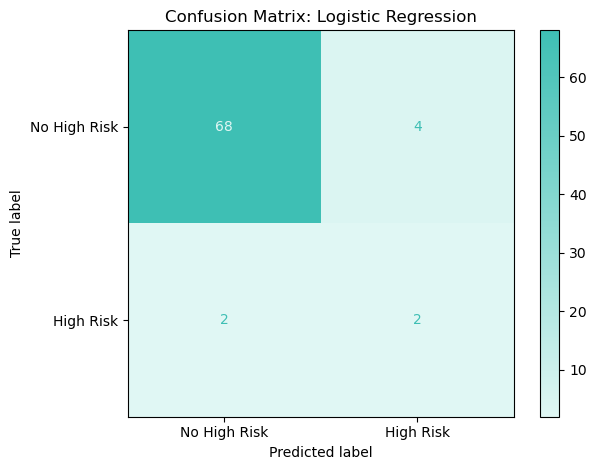

In [62]:
# Importing confusion matrix and metrics tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Importing matplotlib for plotting
import matplotlib.pyplot as plt

# Importing LinearSegmentedColormap to create a custom turquoise colormap
from matplotlib.colors import LinearSegmentedColormap

# Creating a custom turquoise colormap from light to medium shade
turquoise_cmap = LinearSegmentedColormap.from_list(
    "turquoise_shades", ["#E0F7F4", "#3EBFB4"]
)

# Computing the confusion matrix for Logistic Regression
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Printing the confusion matrix title
print("Confusion Matrix: Logistic Regression")

# Showing the raw confusion matrix numbers
print(cm_logistic)

# Creating a visual display object for the confusion matrix
display_cm_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["No High Risk", "High Risk"]
)

# Plotting the confusion matrix with the turquoise colormap
display_cm_lr.plot(cmap=turquoise_cmap)

# Adding a title to the chart
plt.title("Confusion Matrix: Logistic Regression")

# Adjusting the layout
plt.tight_layout()

# Displaying the chart
plt.show()

In [63]:
# Calculating accuracy for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_logistic)

# Calculating precision for Logistic Regression
precision_lr = precision_score(y_test, y_pred_logistic, zero_division=0)

# Calculating recall for Logistic Regression
recall_lr = recall_score(y_test, y_pred_logistic, zero_division=0)

# Calculating F1 score for Logistic Regression
f1_lr = f1_score(y_test, y_pred_logistic, zero_division=0)

# Printing the evaluation metrics title
print("Logistic Regression Evaluation Metrics:")

# Printing accuracy
print("Accuracy: ", round(accuracy_lr, 4))

# Printing precision
print("Precision:", round(precision_lr, 4))

# Printing recall
print("Recall:   ", round(recall_lr, 4))

# Printing F1 score
print("F1 Score: ", round(f1_lr, 4))

Logistic Regression Evaluation Metrics:
Accuracy:  0.9211
Precision: 0.3333
Recall:    0.5
F1 Score:  0.4


In [64]:
# Importing classification report for detailed per-class metrics
from sklearn.metrics import classification_report

# Printing the classification report title
print("Classification Report: Logistic Regression")

# Showing the full classification report
print(classification_report(
    y_test, y_pred_logistic,
    target_names=["No High Risk", "High Risk"],
    zero_division=0
))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

No High Risk       0.97      0.94      0.96        72
   High Risk       0.33      0.50      0.40         4

    accuracy                           0.92        76
   macro avg       0.65      0.72      0.68        76
weighted avg       0.94      0.92      0.93        76



#### Step 9: Training and Evaluating SVM

Support Vector Machine is the second model I will train. It works by finding the best possible boundary between the two classes in the feature space.

I use a Radial Basis Function kernel which allows the model to find non-linear boundaries. This means SVM can capture more complex patterns compared to Logistic Regression.

**Why class_weight equal to balanced is used here:**

The same class imbalance problem that affected Logistic Regression in Assignment 2 applies to SVM as well. With only 5.3 percent of customers labelled as High Risk, a model trained without any adjustment would simply learn to predict No for everything and achieve a misleadingly high accuracy. In Assignment 2, Logistic Regression without class_weight scored 0 percent recall because of this exact issue.

To address this in Assignment 3, I apply class_weight equal to balanced to the SVM model as well. This increases the penalty for missing a High Risk customer during training, encouraging the model to actively look for patterns in the minority class rather than ignoring it entirely.

After training I evaluate SVM using the same four metrics so the comparison with Logistic Regression is fair.

In [65]:
# Importing SVC for Support Vector Classification
from sklearn.svm import SVC

# Creating the SVM model with RBF kernel
# class_weight="balanced" is added for the same reason as Logistic Regression
# Assignment 2 demonstrated that without it the model predicts No for almost every customer
# and scores 0 percent on recall and F1, completely failing to detect the High Risk class
svm_model = SVC(kernel="rbf", random_state=42, class_weight="balanced")

# Training the model using the preprocessed training data
svm_model.fit(X_train_preprocessed, y_train)

# Confirming the model was trained successfully
print("SVM model trained successfully!")

SVM model trained successfully!


In [66]:
# Using the trained SVM model to predict on the test set
y_pred_svm = svm_model.predict(X_test_preprocessed)

# Confirming predictions were completed
print("SVM predictions completed!")

# Printing the first 10 predictions
print("\nFirst 10 SVM predictions:")

# Showing the first 10 predicted values
print(y_pred_svm[:10])

SVM predictions completed!

First 10 SVM predictions:
[0 0 0 0 0 0 0 0 0 0]


Confusion Matrix: SVM
[[70  2]
 [ 4  0]]


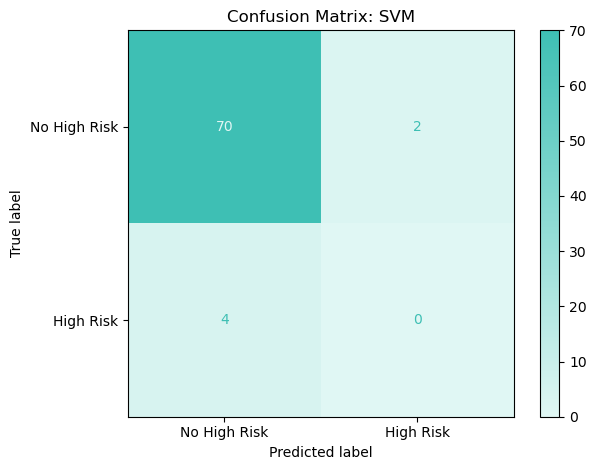

In [67]:
# Computing the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Printing the confusion matrix title
print("Confusion Matrix: SVM")

# Showing the raw confusion matrix numbers
print(cm_svm)

# Creating a visual display object for the SVM confusion matrix
display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No High Risk", "High Risk"]
)

# Plotting the SVM confusion matrix with the turquoise colormap
display_cm_svm.plot(cmap=turquoise_cmap)

# Adding a title to the chart
plt.title("Confusion Matrix: SVM")

# Adjusting the layout
plt.tight_layout()

# Displaying the chart
plt.show()

In [68]:
# Calculating accuracy for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Calculating precision for SVM
precision_svm = precision_score(y_test, y_pred_svm, zero_division=0)

# Calculating recall for SVM
recall_svm = recall_score(y_test, y_pred_svm, zero_division=0)

# Calculating F1 score for SVM
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

# Printing the SVM evaluation metrics title
print("SVM Evaluation Metrics:")

# Printing accuracy
print("Accuracy: ", round(accuracy_svm, 4))

# Printing precision
print("Precision:", round(precision_svm, 4))

# Printing recall
print("Recall:   ", round(recall_svm, 4))

# Printing F1 score
print("F1 Score: ", round(f1_svm, 4))

SVM Evaluation Metrics:
Accuracy:  0.9211
Precision: 0.0
Recall:    0.0
F1 Score:  0.0


In [69]:
# Printing the SVM classification report title
print("Classification Report: SVM")

# Showing the full SVM classification report
print(classification_report(
    y_test, y_pred_svm,
    target_names=["No High Risk", "High Risk"],
    zero_division=0
))

Classification Report: SVM
              precision    recall  f1-score   support

No High Risk       0.95      0.97      0.96        72
   High Risk       0.00      0.00      0.00         4

    accuracy                           0.92        76
   macro avg       0.47      0.49      0.48        76
weighted avg       0.90      0.92      0.91        76



#### Step 10: Comparing the Two Models

Now that both models have been trained and evaluated, I compare their results side by side.

I create a comparison table showing all four metrics for both models. I also create a bar chart to make the difference easier to see.

This comparison helps me decide which model is better for this business problem.

In [70]:
# Importing numpy for numerical operations
import numpy as np

# Creating a comparison DataFrame with both models metrics
model_comparison = pd.DataFrame({
    "Model":     ["Logistic Regression", "SVM"],
    "Accuracy":  [round(accuracy_lr, 4),  round(accuracy_svm, 4)],
    "Precision": [round(precision_lr, 4), round(precision_svm, 4)],
    "Recall":    [round(recall_lr, 4),    round(recall_svm, 4)],
    "F1 Score":  [round(f1_lr, 4),        round(f1_svm, 4)]
})

# Printing the comparison table title
print("Model Comparison Results:")

# Displaying the comparison table
display(model_comparison)

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9211,0.3333,0.5,0.4
1,SVM,0.9211,0.0000,0.0,0.0


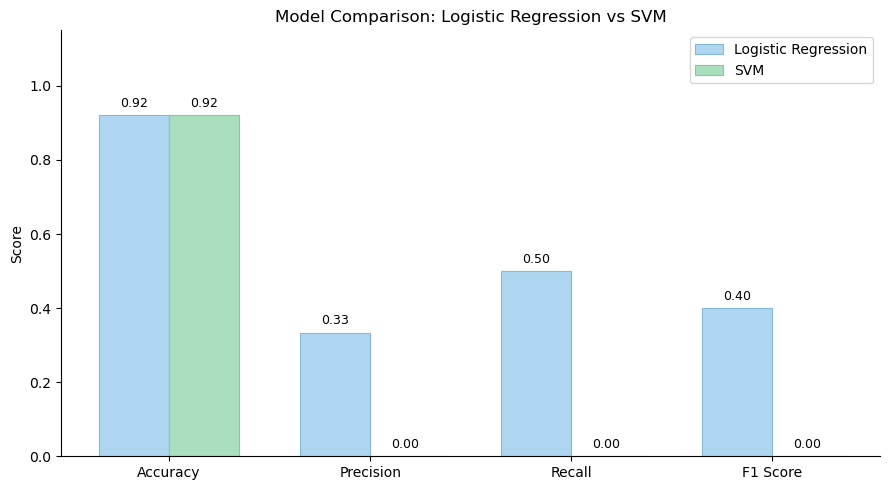

In [71]:
# Defining the metric names for the chart
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Storing the scores for each model
lr_scores  = [accuracy_lr, precision_lr, recall_lr, f1_lr]
svm_scores = [accuracy_svm, precision_svm, recall_svm, f1_svm]

# Setting up the bar positions
x     = np.arange(len(metrics))
width = 0.35

# Creating the figure
fig, ax = plt.subplots(figsize=(9, 5))

# Plotting Logistic Regression bars in pastel blue
bars_lr = ax.bar(
    x - width / 2, lr_scores, width,
    label="Logistic Regression",
    color="#AED6F1", edgecolor="#85B9D6", linewidth=0.8
)

# Plotting SVM bars in pastel green
bars_svm = ax.bar(
    x + width / 2, svm_scores, width,
    label="SVM",
    color="#A9DFBF", edgecolor="#82C9A0", linewidth=0.8
)

# Adding value labels on top of each Logistic Regression bar
for bar in bars_lr:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=9
    )

# Adding value labels on top of each SVM bar
for bar in bars_svm:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=9
    )

# Setting axis labels and title
ax.set_ylabel("Score")
ax.set_title("Model Comparison: Logistic Regression vs SVM")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.legend()

# Removing the top and right borders for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjusting the layout
plt.tight_layout()

# Displaying the chart
plt.show()

In [72]:
# Saving the model comparison results to a CSV file
model_comparison.to_csv(output_dir / "model_comparison_results.csv", index=False)

# Confirming the comparison file was saved
print("Model comparison results saved to:", output_dir / "model_comparison_results.csv")

# Creating a DataFrame with actual and predicted values for both models
classification_output_df = pd.DataFrame({
    "Actual":        y_test.values,
    "Predicted_LR":  y_pred_logistic,
    "Predicted_SVM": y_pred_svm
})

# Saving the classification outputs to a CSV file
classification_output_df.to_csv(output_dir / "classification_outputs.csv", index=False)

# Confirming the classification outputs file was saved
print("Classification outputs saved to:", output_dir / "classification_outputs.csv")

# Listing all files saved in the output folder
print("\nFiles in output folder:")

# Looping through all files in the output folder
for f in sorted(output_dir.iterdir()):
    # Printing each file name
    print(" ", f.name)

Model comparison results saved to: output\model_comparison_results.csv
Classification outputs saved to: output\classification_outputs.csv

Files in output folder:
  classification_outputs.csv
  cleaned_dataset.csv
  model_comparison_results.csv


#### Task 2: Compare the Results and Interpret Them


#### Question 1: Which model performed better?

Logistic Regression performed better than SVM on this dataset.

Both models achieved the same overall accuracy of 92.11 percent. However accuracy alone is not a useful measure here because the dataset is heavily imbalanced.

When I look at the metrics that matter for finding the rare High Risk class:

1. Recall: Logistic Regression correctly identified 2 out of 4 actual High Risk customers giving a recall of 50 percent. SVM identified none of them giving a recall of 0 percent.
2. Precision: Logistic Regression had a precision of 33.33 percent meaning 2 out of its 6 High Risk predictions were correct. SVM had a precision of 0 percent.
3. F1 Score: Logistic Regression scored 40 percent. SVM scored 0 percent.

Logistic Regression is the better model for this problem because it actually detected some of the High Risk customers while SVM completely missed all of them.

It is also important to note that in Assignment 2, Logistic Regression was trained without class_weight="balanced" on the same dataset. That model scored 93.42 percent accuracy but achieved 0 percent precision, 0 percent recall and 0 percent F1 for the High Risk class. It was predicting No High Risk for almost every customer. In Assignment 3 I added class_weight="balanced" to both models as a direct response to that limitation. This change improved Logistic Regression recall from 0 percent to 50 percent, showing that the adjustment made a meaningful difference. SVM still scored 0 percent recall despite the same fix, which shows that SVM with an RBF kernel struggles more with this extreme class imbalance when the minority class has very few training examples.


#### Question 2: Which metric is most important for this business problem?

Recall is the most important metric for this business problem.

Recall measures how many of the actual High Risk customers the model correctly identified. In a financial setting the goal is to catch as many high risk customers as possible so that advisors can intervene early. Missing a high risk customer is a much more serious mistake than incorrectly flagging a safe customer.

A customer who is incorrectly flagged as high risk will simply receive more careful attention from an advisor which is not harmful. But a customer who is actually high risk and goes undetected could face serious financial losses without any support.

For this reason I want recall to be as high as possible even if it means some false alarms.


#### Question 3: What do false positives and false negatives mean in this dataset?

A false positive means the model predicted that a customer is High Risk but the customer is actually not high risk. In this business context this means a safe customer is treated as risky. The financial advisor will give extra attention to that customer which is a minor inconvenience but not harmful.

A false negative means the model predicted that a customer is not High Risk but the customer actually is high risk. In this business context this means a genuinely risky customer is missed completely. The advisor does not reach out to this customer and the customer may make poor financial decisions without guidance. This is the more dangerous mistake.

In the Logistic Regression model there were 4 false positives and 2 false negatives.
In the SVM model there were 2 false positives and 4 false negatives.

Logistic Regression is preferred here because it produces fewer false negatives even though it produces more false positives.


#### Question 4: What is one possible limitation or bias in the model?

The most important limitation is the severe class imbalance in the dataset. Only 20 out of 380 customers are labelled as High Risk which is 5.3 percent. This was the exact problem discovered in Assignment 2 where Logistic Regression without any adjustment completely failed on the minority class scoring 0 percent recall.

Even after adding class_weight="balanced" in Assignment 3 to correct for this imbalance, both models still struggled. Logistic Regression improved significantly but SVM still scored 0 percent recall. This shows that class weighting alone is not always enough to overcome extreme imbalance when the training set has very few minority examples. With only 16 High Risk customers in the training set the models have very little information about what makes a customer truly high risk and cannot reliably generalise to new cases.

This could also introduce bias. If the rare High Risk customers share some demographic characteristic such as age group or employment status the model may incorrectly learn to use that characteristic as the main signal for risk rather than actual financial behaviour.


#### Question 5: Why should human judgment still be used?

Even the better model Logistic Regression only detected 2 out of 4 actual High Risk customers in the test set. This means 50 percent of real high risk customers were still missed. And this result came only after improving the model with class_weight="balanced" compared to Assignment 2 where the same model missed 100 percent of them. The improvement shows the value of deliberate design choices, but the results also show that the model is still far from reliable enough to be used alone.

A human advisor looking at the full picture including conversations with the customer and knowledge of current market conditions would likely catch many of the cases the model misses.

Machine learning models learn from past data but financial behaviour changes over time. A customer who was safe last year may become high risk due to job loss or market changes that the model has never seen before. Human advisors can adapt to these changes in real time.

The model should be used as a tool to assist advisors by flagging likely high risk customers for review. The final decision about how to classify and support each customer should always involve human judgment.